# Challenge 1: datos y análisis exploratorio

Tu primera responsabilidad es preparar una fuente de datos confiable para el proyecto de clasificación de vinos.

**Entrada:** `data/raw/wine.csv`  
**Salidas:** `data/processed/train.csv`, `data/processed/test.csv` y `artifacts/data_contract.json`

> El conjunto de test se crea aquí, pero no debe explorarse ni utilizarse después del split.

## Objetivos

- cargar y validar datos externos;
- identificar problemas básicos de calidad;
- crear un split reproducible y estratificado;
- realizar EDA únicamente sobre entrenamiento;
- guardar datos y metadatos para la siguiente etapa.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 4)

In [2]:
from pathlib import Path

PROJECT_DIR = Path.cwd()
RAW_DATA_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
REPORTS_DIR = PROJECT_DIR / "reports"

for directory in (PROCESSED_DATA_DIR, ARTIFACTS_DIR, REPORTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## 1. Carga y profiling

In [3]:
DATA_PATH = RAW_DATA_DIR / "wine.csv"

# Carga el archivo en un DataFrame llamado df
df = pd.read_csv(DATA_PATH)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
# Profiling: forma, tipos, nulos, duplicados y distribución del target
print("Forma (filas, columnas):", df.shape)
print("\n--- Tipos de dato ---")
print(df.dtypes)
print("\n--- Valores nulos por columna ---")
print(df.isnull().sum())
print("\n--- Filas duplicadas ---")
print("Duplicados:", df.duplicated().sum())
print("\n--- Distribución del target ---")
print(df["target"].value_counts().sort_index())
print("\n--- Proporción del target ---")
print(df["target"].value_counts(normalize=True).sort_index().round(3))
print("\n--- Estadísticos descriptivos ---")
df.describe().T

Forma (filas, columnas): (178, 14)

--- Tipos de dato ---
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object

--- Valores nulos por columna ---
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity            

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


**Conclusión de calidad:**

> El dataset tiene **178 vinos** y **14 columnas** (13 características numéricas + `target`). Todas las columnas son numéricas (`float64` para los features, `int64` para el target), **no hay valores nulos** y **no hay filas duplicadas**. El `target` tiene **3 clases** (0, 1, 2) con una distribución **ligeramente desbalanceada** pero sin casos extremos (aprox. 33% / 40% / 27%). Las escalas de las variables son muy distintas (p. ej. `proline` llega a ~1000 mientras `hue` ronda 1), lo que anticipa la necesidad de **estandarizar** para modelos sensibles a la escala (KNN, regresión logística). **Decisión:** los datos son usables tal cual; aplicaremos un split estratificado por `target` y dejaremos la estandarización dentro de los pipelines del Challenge 2.

## 2. Split train/test

In [5]:
# Crea train_df (80 %) y test_df (20 %) con estratificación y semilla fija
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["target"],
    random_state=RANDOM_STATE,
)

In [6]:
# Verificación del split
assert len(train_df) + len(test_df) == len(df)
assert set(train_df.index).isdisjoint(set(test_df.index))
print("Train:", train_df.shape)
print("Test:", test_df.shape)
print("\nProporción target en TRAIN:")
print(train_df["target"].value_counts(normalize=True).sort_index().round(3))
print("\nProporción target en TEST:")
print(test_df["target"].value_counts(normalize=True).sort_index().round(3))

Train: (142, 14)
Test: (36, 14)

Proporción target en TRAIN:
target
0    0.331
1    0.401
2    0.268
Name: proportion, dtype: float64

Proporción target en TEST:
target
0    0.333
1    0.389
2    0.278
Name: proportion, dtype: float64


## 3. EDA sobre entrenamiento

Incluye:

- distribución de clases;
- distribuciones o boxplots de variables relevantes;
- correlaciones;
- tres hallazgos que puedan influir en el modelado.

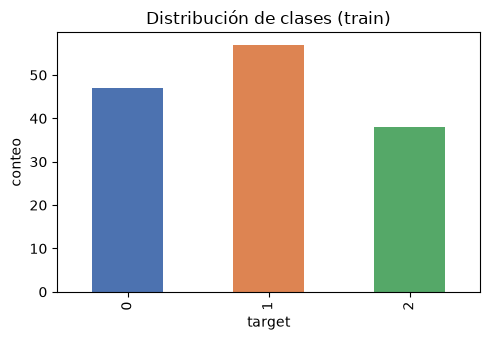

In [7]:
# EDA usando SOLAMENTE train_df (nunca test_df)

# (1) Distribución de clases
fig, ax = plt.subplots(figsize=(5, 3.5))
train_df["target"].value_counts().sort_index().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_title("Distribución de clases (train)")
ax.set_xlabel("target"); ax.set_ylabel("conteo")
plt.tight_layout(); plt.show()

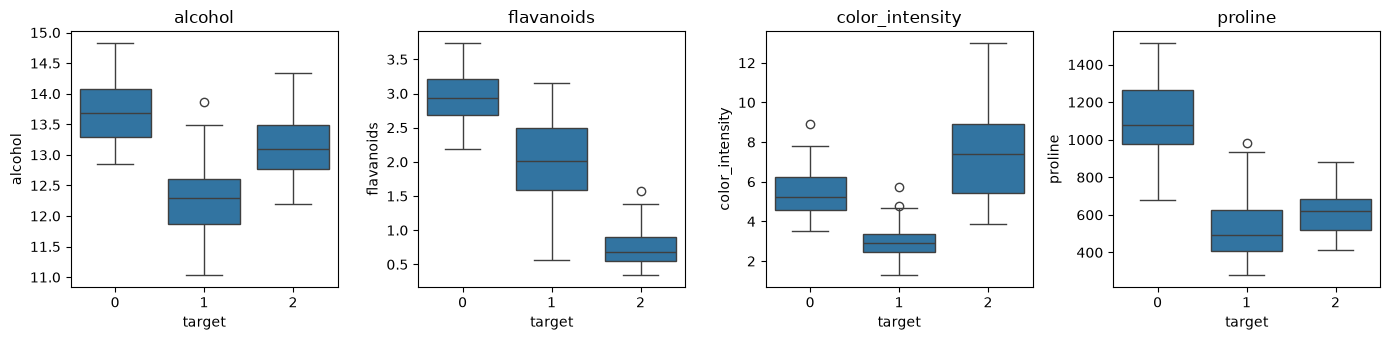

In [8]:
# (2) Boxplots de variables con escalas y poder discriminante relevantes
feat_box = ["alcohol", "flavanoids", "color_intensity", "proline"]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, col in zip(axes, feat_box):
    sns.boxplot(data=train_df, x="target", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout(); plt.show()

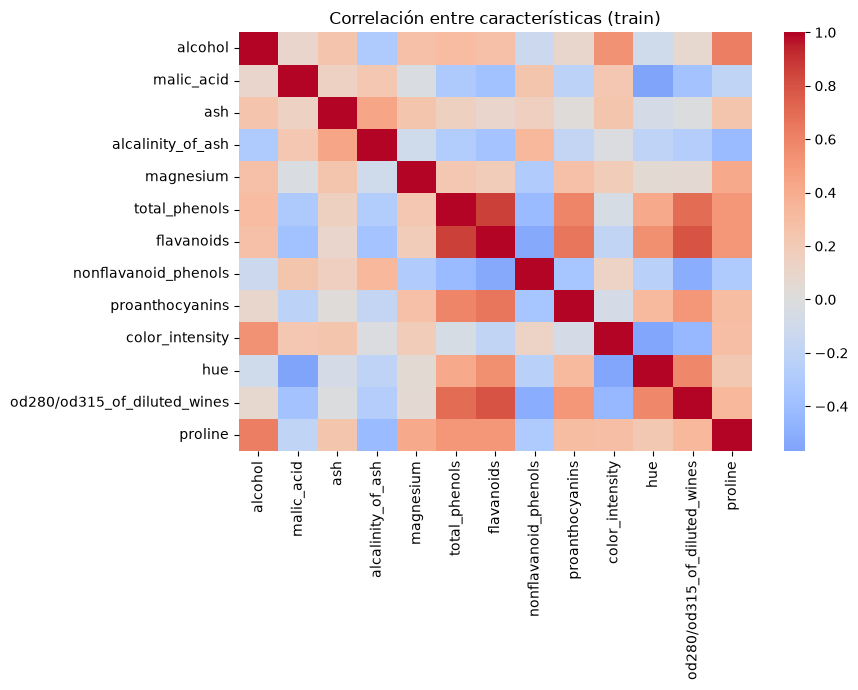

Correlación de cada feature con target:
flavanoids                     -0.870
od280/od315_of_diluted_wines   -0.784
total_phenols                  -0.714
proline                        -0.639
hue                            -0.606
proanthocyanins                -0.481
alcohol                        -0.332
magnesium                      -0.208
ash                            -0.045
color_intensity                 0.269
malic_acid                      0.418
nonflavanoid_phenols            0.477
alcalinity_of_ash               0.508
Name: target, dtype: float64


In [9]:
# (3) Matriz de correlación entre features (train)
features = [c for c in train_df.columns if c != "target"]
corr = train_df[features].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, ax=ax)
ax.set_title("Correlación entre características (train)")
plt.tight_layout(); plt.show()

# Correlación de cada feature con el target (ayuda a leer poder discriminante)
corr_target = train_df[features + ["target"]].corr()["target"].drop("target").sort_values()
print("Correlación de cada feature con target:")
print(corr_target.round(3))

**Hallazgos:**

1. **Las clases son bastante separables.** Variables como `flavanoids`, `od280/od315_of_diluted_wines` y `proline` muestran medianas claramente distintas por clase en los boxplots, lo que anticipa que incluso modelos simples lograrán alta accuracy.
2. **Las escalas difieren en órdenes de magnitud.** `proline` (cientos–miles) frente a `hue` o `nonflavanoid_phenols` (<1). Esto obliga a **estandarizar** para KNN y regresión logística; los árboles, en cambio, son invariantes a la escala.
3. **Hay correlaciones fuertes entre features** (p. ej. `flavanoids` con `total_phenols` y con `od280/od315`). Existe redundancia/colinealidad: la regularización en la regresión logística y la selección de atributos de los árboles ayudarán a manejarla.

## 4. Persistencia de datos y contrato

In [10]:
# Reinicia índices y guarda train.csv y test.csv SIN el índice
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_df.to_csv(PROCESSED_DATA_DIR / "train.csv", index=False)
test_df.to_csv(PROCESSED_DATA_DIR / "test.csv", index=False)

# Contrato de datos: target, features, random_state y test_size
feature_columns = [c for c in df.columns if c != "target"]
data_contract = {
    "target": "target",
    "features": feature_columns,
    "random_state": RANDOM_STATE,
    "test_size": 0.20,
    "n_classes": int(df["target"].nunique()),
    "n_samples_total": int(len(df)),
    "n_train": int(len(train_df)),
    "n_test": int(len(test_df)),
}
(ARTIFACTS_DIR / "data_contract.json").write_text(
    json.dumps(data_contract, indent=2), encoding="utf-8"
)
print(json.dumps(data_contract, indent=2))

{
  "target": "target",
  "features": [
    "alcohol",
    "malic_acid",
    "ash",
    "alcalinity_of_ash",
    "magnesium",
    "total_phenols",
    "flavanoids",
    "nonflavanoid_phenols",
    "proanthocyanins",
    "color_intensity",
    "hue",
    "od280/od315_of_diluted_wines",
    "proline"
  ],
  "random_state": 42,
  "test_size": 0.2,
  "n_classes": 3,
  "n_samples_total": 178,
  "n_train": 142,
  "n_test": 36
}


In [11]:
# Verificación de entrega
assert (PROCESSED_DATA_DIR / "train.csv").exists()
assert (PROCESSED_DATA_DIR / "test.csv").exists()
assert (ARTIFACTS_DIR / "data_contract.json").exists()
print("Challenge 1 completado.")

Challenge 1 completado.


## Checklist

- [x] Cargué el CSV desde `data/raw`.
- [x] Revisé calidad y distribución de la clase.
- [x] Realicé un split estratificado.
- [x] No exploré el conjunto de test.
- [x] Guardé los tres artefactos requeridos.